# CLIP Zero-Shot 图像分类：小狗示例

这个 Notebook 参考 `01-CLIP模型.ipynb` 的本地 `ChineseCLIPModel` 用法，使用一张本地小狗图片做 zero-shot classification。

默认图片：`demo_assets/dog_sample.jpg`

默认模型：`model/chinese-clip-vit-base-patch16`

## 1. 导入依赖

In [1]:
from pathlib import Path

from PIL import Image
from IPython.display import display
from transformers import ChineseCLIPProcessor, ChineseCLIPModel
import torch
import torch.nn.functional as F


## 2. 设置路径与候选标签

你可以修改 `IMAGE_PATH` 和 `CANDIDATE_LABELS` 后重新运行。

In [2]:
BASE_DIR = Path.cwd()
MODEL_PATH = BASE_DIR / 'model' / 'chinese-clip-vit-base-patch16'
IMAGE_PATH = BASE_DIR / 'demo_assets' / 'dog_sample.jpg'

CANDIDATE_LABELS = [
    '狗',
    '猫',
    '狐狸',
    '狼',
    '兔子',
    '鸟',
    '马',
    '牛',
    '人',
    '汽车',
]

print('MODEL_PATH =', MODEL_PATH)
print('IMAGE_PATH =', IMAGE_PATH)
print('候选标签 =', CANDIDATE_LABELS)


MODEL_PATH = /Users/xinjianrun/Desktop/架构师资料包/AI大模型课程/第10周：多模态大模型/Week10/model/chinese-clip-vit-base-patch16
IMAGE_PATH = /Users/xinjianrun/Desktop/架构师资料包/AI大模型课程/第10周：多模态大模型/Week10/demo_assets/dog_sample.jpg
候选标签 = ['狗', '猫', '狐狸', '狼', '兔子', '鸟', '马', '牛', '人', '汽车']


## 3. 查看测试图片

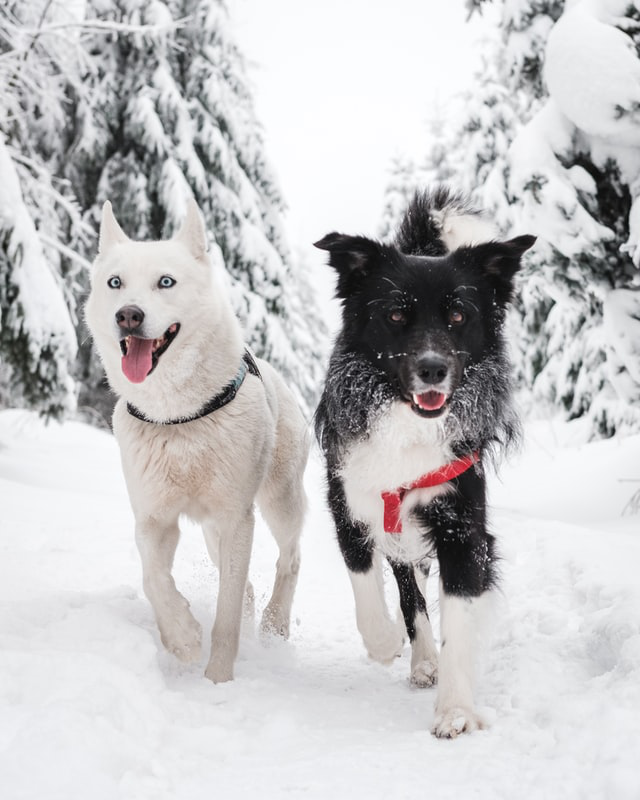

In [3]:
image = Image.open(IMAGE_PATH).convert('RGB')
display(image)


## 4. 加载本地 Chinese-CLIP 模型

In [4]:
model = ChineseCLIPModel.from_pretrained(MODEL_PATH)
processor = ChineseCLIPProcessor.from_pretrained(MODEL_PATH, use_fast=False)
model.eval()
print('模型加载完成')


模型加载完成


## 5. 定义文本编码函数

这里沿用当前环境下更稳妥的写法：使用 `text_model` 的 `CLS` 向量，再经过 `text_projection`。

In [5]:
def encode_texts(model: ChineseCLIPModel, processor: ChineseCLIPProcessor, texts: list[str]) -> torch.Tensor:
    text_inputs = processor(text=texts, return_tensors='pt', padding=True)
    text_outputs = model.text_model(**text_inputs)
    pooled_output = text_outputs.last_hidden_state[:, 0, :]
    return model.text_projection(pooled_output)


## 6. 运行 zero-shot classification

In [6]:
image_inputs = processor(images=[image], return_tensors='pt')

with torch.no_grad():
    image_features = model.get_image_features(**image_inputs)
    text_features = encode_texts(model, processor, CANDIDATE_LABELS)
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    logits = image_features @ text_features.T
    probs = logits.softmax(dim=-1)[0]

values, indices = probs.topk(min(5, len(CANDIDATE_LABELS)))

results = []
for rank, (value, idx) in enumerate(zip(values.tolist(), indices.tolist()), start=1):
    label = CANDIDATE_LABELS[idx]
    score = logits[0, idx].item()
    results.append((rank, label, value, score))

for rank, label, prob, score in results:
    print(f'{rank}. {label}	prob={prob:.4f}	score={score:.4f}')


1. 狗	prob=0.1061	score=0.3985
2. 狐狸	prob=0.1027	score=0.3656
3. 狼	prob=0.1023	score=0.3616
4. 人	prob=0.1005	score=0.3442
5. 马	prob=0.0991	score=0.3299
